<a href="https://colab.research.google.com/github/isaacadebayo/Predictive-Analytics-Public-Datasets/blob/main/Apple_Stock_prediction_timeseries_split_fold4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
stocks = pd.read_csv('/content/drive/MyDrive/aapl_stock_prices.csv')
stocks.head()

,Date,Open,High,Low,Close,Volume
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600


In [4]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11407 entries, 0 to 11406
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11407 non-null  object 
 1   Open    11407 non-null  float64
 2   High    11407 non-null  float64
 3   Low     11407 non-null  float64
 4   Close   11407 non-null  float64
 5   Volume  11407 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 534.8+ KB


<Axes: xlabel='Date'>

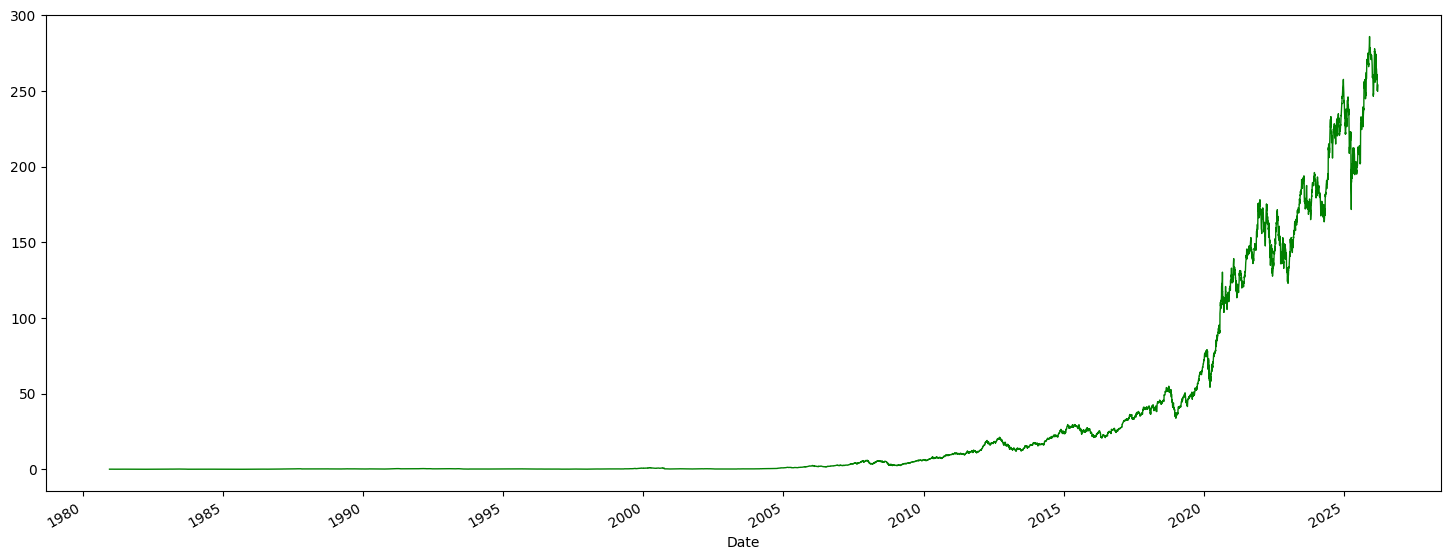

In [5]:
if 'Date' in stocks.columns:
    stocks['Date'] = pd.to_datetime(stocks['Date'])
    stocks = stocks.set_index('Date')
stocks.Close.plot(figsize=(18,7), linewidth=1, c='g')

,count,mean,std,min,25%,50%,75%,max
Open,11407.0,0.101247,0.208832,0.0,0.000730,0.001587,0.076311,1.0
High,11407.0,0.101485,0.209296,0.0,0.000747,0.001608,0.076484,1.0
Low,11407.0,0.101240,0.208877,0.0,0.000720,0.001572,0.076457,1.0
Close,11407.0,0.101326,0.209009,0.0,0.000733,0.001592,0.076348,1.0
Volume,11407.0,0.041573,0.044884,0.0,0.014212,0.026584,0.052385,1.0


,Open,High,Low,Close,Volume
Open,1.000000,0.999937,0.999940,0.999873,-0.287284
High,0.999937,1.000000,0.999918,0.999943,-0.287010
Low,0.999940,0.999918,1.000000,0.999942,-0.287684
Close,0.999873,0.999943,0.999942,1.000000,-0.287359
Volume,-0.287284,-0.287010,-0.287684,-0.287359,1.000000


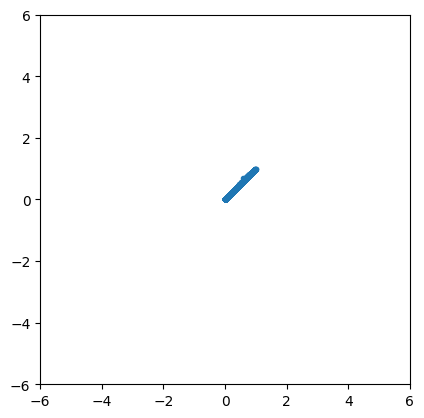

In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(stocks)

df_X_data = pd.DataFrame(X, columns=stocks.columns)
display(df_X_data.describe().T)
display(df_X_data.corr())

plt.plot( X[:,0], X[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

In [7]:
# Create lagged sequences
window_size = 10

#perm = np.arange(window_size)
perm = np.random.permutation(np.arange(window_size))

X, y = [], []
dates = []
for i in range(len(stocks) - window_size):
    X.append(stocks.iloc[i:i+window_size].values)
    # Predict only the 'close' price (index 1) for y
    y.append(stocks.iloc[i+window_size, 1])
    dates.append(stocks.index[i+window_size])

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (11397, 10, 5), y shape: (11397,)


In [8]:
# Simple index-based split
split_idx = int(len(X) * 0.9)
X_train, y_train, dates_train = X[:split_idx], y[:split_idx], dates[:split_idx]
X_test, y_test, dates_test = X[split_idx:], y[split_idx:], dates[split_idx:]

# Reshape X_train and X_test to be 2D for scikit-learn models
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")

Train: X=(10257, 50), y=(10257,)
Test:  X=(1140, 50), y=(1140,)


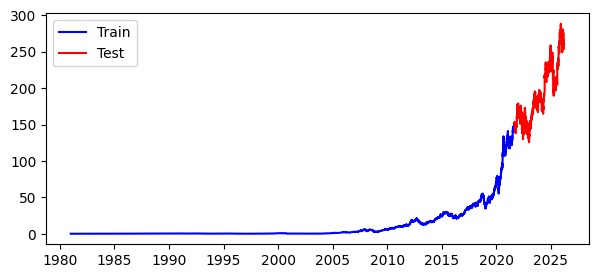

In [9]:
plt.figure(figsize=(7,3))
# y_train and y_test are now 1D arrays
plt.plot( dates_train, y_train, 'b', label='Train' );
plt.plot( dates_test, y_test, 'r', label='Test' );
plt.legend()

# Cross Validation

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=4, weights='uniform'),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=30, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5),
]

In [11]:
from sklearn.model_selection import cross_val_score, KFold, TimeSeriesSplit

#kf = KFold(n_splits=5, shuffle=True)
kf = TimeSeriesSplit(n_splits=5)

# Reshape X to be 2-dimensional for scikit-learn models
X_2d = X.reshape(X.shape[0], -1)

for m in models:
    print(m)

    cv_scores = -cross_val_score(m, X_2d, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
    cv_scores = pd.DataFrame(cv_scores)
    display(cv_scores.describe().T)

    print()
# end

LinearRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.013096,0.004347,0.008178,0.010107,0.013391,0.014315,0.019491



KNeighborsRegressor(n_neighbors=4)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.681178,0.220379,0.407991,0.491296,0.763472,0.825116,0.918012



RandomForestRegressor(max_depth=5, n_estimators=10)


...

,count,mean,std,min,25%,50%,75%,max
0,5.0,0.325036,0.253886,0.0278,0.070811,0.468814,0.505658,0.552095



GradientBoostingRegressor()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.325286,0.254985,0.02723,0.069425,0.467673,0.510861,0.551238



GradientBoostingRegressor(max_depth=5)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.325863,0.255151,0.027604,0.06975,0.467888,0.513739,0.550334


# Grid SearchCV

In [12]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    )
}

# Define cross-validation strategy
#kf = KFold(n_splits=5, shuffle=True)
kf = TimeSeriesSplit(n_splits=5)

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X_2d, y)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.6678828869235495),
  'Best Params': {'n_neighbors': 50, 'weights': 'uniform'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.32608295566055123),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 5,
   'n_estimators': 10}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.3248481516552118),
  'Best Params': {'learning_rate': 0.1,
   'max_depth': 3,
   'min_samples_leaf': 1,
   'n_estimators': 200}}]

# Feature Importance










In [13]:
# Fit a Random Forest model
rf = RandomForestRegressor(n_estimators=1000)
rf.fit(X_2d, y)

# Generate feature names for X_2d
original_features = stocks.columns.tolist()
feature_names_for_X_2d = []
for lag in range(window_size, 0, -1): # Lags from window_size down to 1
    for col in original_features:
        feature_names_for_X_2d.append(f'{col}_lag{lag}')

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=feature_names_for_X_2d).sort_values(ascending=False)
importances = importances[:20]

# Get the names of the selected features
features_rf = importances.index.tolist()

# Create a DataFrame from X_2d with the correct column names for easier slicing
X_2d_df = pd.DataFrame(X_2d, columns=feature_names_for_X_2d)

# Select only the important features from X_2d_df
X_pars = X_2d_df[features_rf]

importances

,0
Close_lag1,0.510329
Low_lag1,0.231789
High_lag1,0.091992
Close_lag2,0.046057
Low_lag2,0.031692
Open_lag1,0.021016
Low_lag3,0.018457
High_lag2,0.013606
Close_lag3,0.009819
Open_lag2,0.004566


# KERAS

In [14]:
!pip install tensorflow

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=X_train.shape[1]),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='relu'),
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [16]:
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Re-defining build_model with the fix for the Input layer
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])), # Corrected: Input layer now expects 3D shape
        Flatten(), # Added: Flatten the input for Dense layers
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='linear'), # Changed activation to 'linear' for regression
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

epochs                = 500
batch_size            = 256
decay_frac            = 0.8
dropout_rate          = 0.25
initial_learning_rate = 0.01

n_splits = 5
#kf = KFold(n_splits=n_splits, shuffle=True)
kf = TimeSeriesSplit(n_splits=n_splits)

train_mae_list = []
test_mae_list = []
train_r2_list = []
test_r2_list = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f"Fold {fold}/{n_splits}")
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Scale X_train_fold and y_train_fold for the neural network
    # Flatten X_train_fold and X_test_fold for scaling, then reshape back
    scaler_X = MinMaxScaler(feature_range=(0,1))
    X_train_flat = X_train_fold.reshape(X_train_fold.shape[0], -1)
    X_test_flat = X_test_fold.reshape(X_test_fold.shape[0], -1)

    X_train_scaled = scaler_X.fit_transform(X_train_flat)
    X_test_scaled = scaler_X.transform(X_test_flat)

    X_train_scaled = X_train_scaled.reshape(X_train_fold.shape)
    X_test_scaled = X_test_scaled.reshape(X_test_fold.shape)

    scaler_y = MinMaxScaler(feature_range=(0,1))
    y_train_scaled = scaler_y.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test_fold.reshape(-1, 1))

    # Build a fresh model (which resets optimizer state including the learning rate schedule)
    model = build_model(
        X_train_scaled,
        epochs,
        batch_size,
        decay_frac,
        initial_learning_rate,
        dropout_rate
    )

    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=100,          # Stop after 5 epochs without improvement
        restore_best_weights=True  # Restore the best weights after stopping
    )

    # Train the model
    history = model.fit(
        X_train_scaled, y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled, y_test_scaled),
        verbose=0,
        callbacks=[early_stopping]
    )

    # Evaluate on training data
    y_train_pred_scaled = model.predict(X_train_scaled, verbose=0)
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled) # Inverse transform predictions
    train_mae = mean_absolute_error(y_train_fold, y_train_pred)
    train_r2 = r2_score(y_train_fold, y_train_pred)

    # Evaluate on test data
    y_test_pred_scaled = model.predict(X_test_scaled, verbose=0)
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled) # Inverse transform predictions
    test_mae = mean_absolute_error(y_test_fold, y_test_pred)
    test_r2 = r2_score(y_test_fold, y_test_pred)

    print("MAE:")
    print(f"  Train: {train_mae:.4f}")
    print(f"  Test:  {test_mae:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2:.4f}")
    print(f"  Test:  {test_r2:.4f}")
    print()

    train_mae_list.append(train_mae)
    test_mae_list.append(test_mae)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)

    fold += 1
# end

Fold 1/5
MAE:
  Train: 0.0230
  Test:  0.0780
R^2:
  Train: 0.8197
  Test:  -0.4091

Fold 2/5
MAE:
  Train: 0.0563
  Test:  0.0957
R^2:
  Train: 0.6604
  Test:  0.6435

Fold 3/5
MAE:
  Train: 0.0671
  Test:  1.1581
R^2:
  Train: 0.6999
  Test:  0.6774

Fold 4/5
MAE:
  Train: 0.3569
  Test:  7.1481
R^2:
  Train: 0.8620
  Test:  0.3607

Fold 5/5
MAE:
  Train: 1.4313
  Test:  48.0988
R^2:
  Train: 0.9118
  Test:  0.3519



In [17]:
results_df = pd.DataFrame({
    'Train MAE': train_mae_list,
    'Test MAE': test_mae_list,
    'Train R2': train_r2_list,
    'Test R2': test_r2_list
})

results_df.describe()

,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,0.386921,11.315768,0.790741,0.324896
std,0.599121,20.770881,0.107008,0.437754
min,0.022961,0.078033,0.660366,-0.409083
25%,0.056275,0.095702,0.699924,0.351915
50%,0.067108,1.158141,0.819664,0.360740
75%,0.356925,7.148120,0.861999,0.643484
max,1.431338,48.098845,0.911752,0.677425


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X_pars, y, dates,
                                                    test_size=0.2, random_state=42)

# Model Creation

In [19]:
dropout_rate = 0.1

model_dense  = Sequential([
    Input(shape=(X_train.shape[1],)), # Corrected input shape

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(8, activation='relu'),

    Dense(1, activation='linear'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.01)

# Compile model
model_dense .compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

model_dense .summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 96 (384.00 B)

In [20]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

In [22]:
history_dense = model_dense.fit(
    X_train, y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.9205 - val_loss: 26.7554
Epoch 2/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.9968 - val_loss: 5.5548
Epoch 3/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.1889 - val_loss: 1.7911
Epoch 4/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.3399 - val_loss: 6.4366
Epoch 5/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.8733 - val_loss: 7.9174
Epoch 6/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.0317 - val_loss: 2.0750
Epoch 7/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.1484 - val_loss: 1.7964
Epoch 8/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.7666 - val_loss: 1.7819
Epoch 9/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.1336 - val_loss: 1.2981
Epoch 10/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.0024 - val_loss: 1.6754
Epoch 11/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.6972 - val_loss: 2.0363
Epoch 12/150
143/143 ━━━━━━━━━━━━━━━━━━

285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step
r2_train:   0.99833
r2_test:    0.99826
rmse_train: 2.479
rmse_test:  2.4681


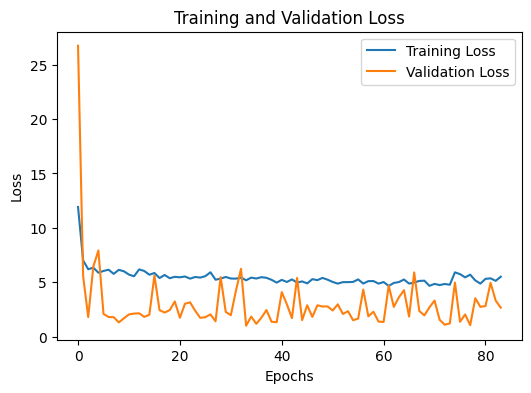

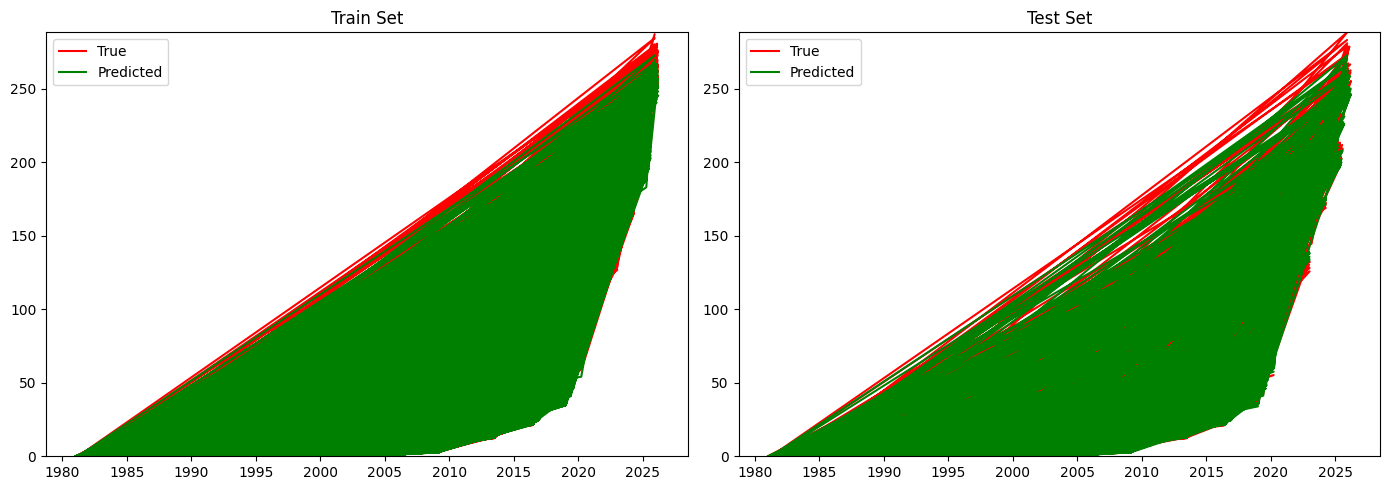

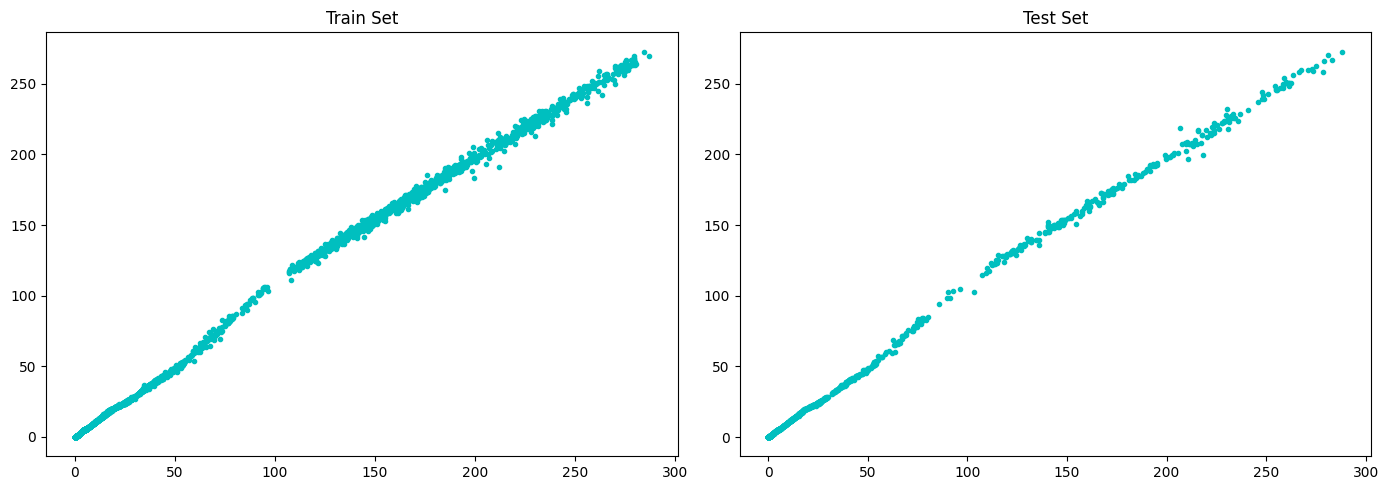

MAE:
  Train: 1.0052
  Test:  0.9938
R^2:
  Train: 0.9983
  Test:  0.9983


In [23]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Get predictions
y_train_pred = model_dense.predict(X_train)[:,0]
y_test_pred  = model_dense.predict(X_test)[:,0]

# Create a figure with two subplots side by side
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Left subplot: Training and Validation Loss
ax.plot(history_dense.history['loss'], label='Training Loss')
ax.plot(history_dense.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()

r2_train = r2_score(y_train, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

y_train_pred = pd.Series(y_train_pred, index=dates_train)
y_test_pred  = pd.Series(y_test_pred, index=dates_test)

# Calculate global y-axis limits
y_min = min(y_train.min(), y_train_pred.min(), y_test.min(), y_test_pred.min())
y_max = max(y_train.max(), y_train_pred.max(), y_test.max(), y_test_pred.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train, y_train, 'r', label='True')
axs[0].plot(y_train_pred, 'g', label='Predicted')
axs[0].set_title('Train Set')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test, y_test, 'r', label='True')
axs[1].plot(y_test_pred, 'g', label='Predicted')
axs[1].set_title('Test Set')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train, y_train_pred.values, 'c.')
axs[0].set_title('Train Set')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test, y_test_pred.values, 'c.')
axs[1].set_title('Test Set')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

# LSTM

In [24]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

In [26]:
X_train_2 = X_train.values.reshape((X_train.shape[0], window_size, X_train.shape[1] // window_size))
X_test_2 = X_test.values.reshape((X_test.shape[0], window_size, X_test.shape[1] // window_size))

model_lstm = Sequential([
    Input(shape=(window_size, X_train.shape[1] // window_size)), # Corrected input shape

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.001)

# Compile model
model_lstm .compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm .summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,913 (120.75 KB)

 Trainable params: 30,785 (120.25 KB)

 Non-trainable params: 128 (512.00 B)

In [27]:
history_lstm = model_lstm.fit(
    X_train_2, y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test_2, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 23.8609 - val_loss: 17.4508
Epoch 2/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 14.4880 - val_loss: 8.9268
Epoch 3/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.6078 - val_loss: 4.3343
Epoch 4/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.2057 - val_loss: 2.1954
Epoch 5/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.7590 - val_loss: 2.4653
Epoch 6/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.4655 - val_loss: 2.1835
Epoch 7/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1993 - val_loss: 1.1544
Epoch 8/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1991 - val_loss: 1.4088
Epoch 9/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0533 - val_loss: 1.6359
Epoch 10/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1784 - val_loss: 1.4880
Epoch 11/150
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0611 - val_loss: 2.4017
Epoch 12/150
143/143 ━━━━━━━━━━━━━━━━━

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


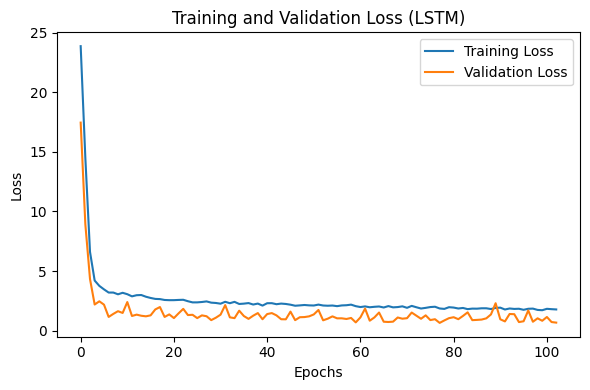

r2_train:   0.99908
r2_test:    0.99887
rmse_train: 1.8352
rmse_test:  1.9946


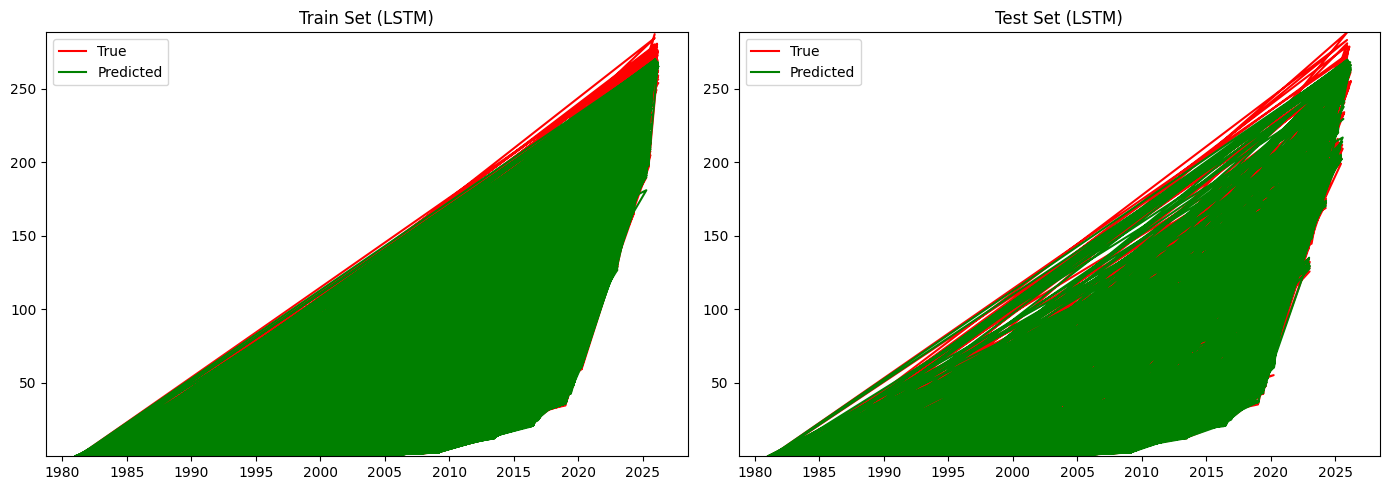

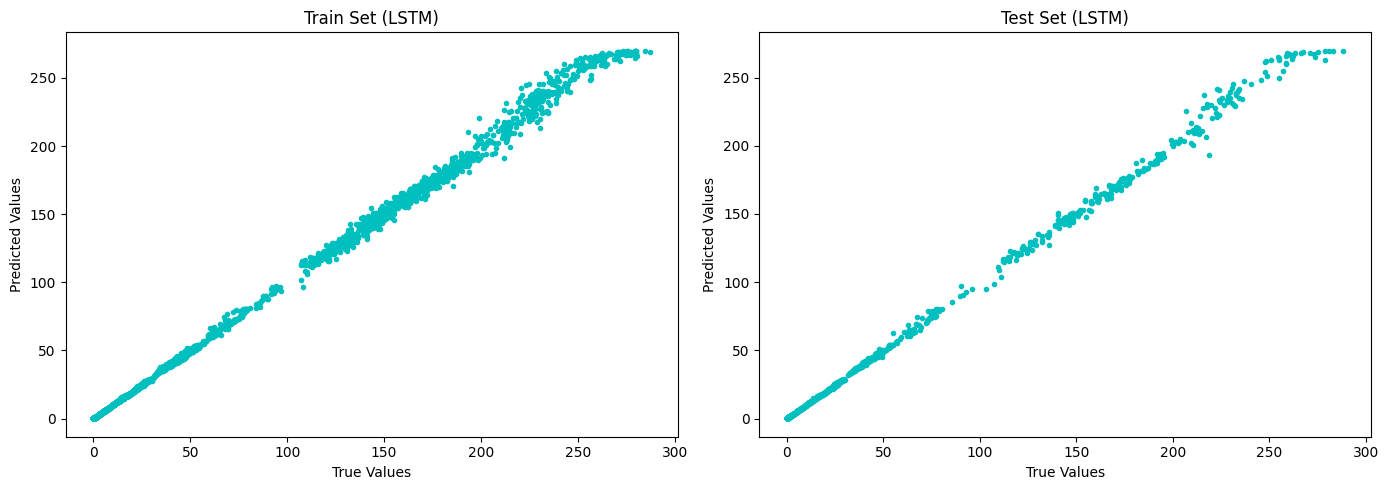

MAE:
  Train: 0.6422
  Test:  0.6554
R^2:
  Train: 0.9991
  Test:  0.9989


In [28]:
# Get predictions
# Use the already reshaped X_train_2 and X_test_2 for LSTM predictions.
y_train_pred = model_lstm.predict(X_train_2)[:,0]
y_test_pred  = model_lstm.predict(X_test_2)[:,0]

# Now use the true values and dates from the train_test_split
y_train_true = y_train
y_test_true = y_test
dates_train_plot = dates_train
dates_test_plot = dates_test

# Create a figure with one subplot for loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot Training and Validation Loss
ax.plot(history_lstm.history['loss'], label='Training Loss')
ax.plot(history_lstm.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss (LSTM)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for LSTM model
r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

# Convert predictions to pandas Series with dates as index for plotting
y_train_pred_series = pd.Series(y_train_pred, index=dates_train_plot)
y_test_pred_series  = pd.Series(y_test_pred, index=dates_test_plot)

# Calculate global y-axis limits for consistent plotting
y_min = min(y_train_true.min(), y_train_pred_series.min(), y_test_true.min(), y_test_pred_series.min())
y_max = max(y_train_true.max(), y_train_pred_series.max(), y_test_true.max(), y_test_pred_series.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred_series, 'g', label='Predicted')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred_series, 'g', label='Predicted')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot scatter plots for train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred_series.values, 'c.')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred_series.values, 'c.')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

In [29]:
# Create a DataFrame to organize the data of true vs pred data graph
predicted_results_df_corrected = pd.DataFrame({
    'Actual Close Price': pd.Series(y_test_true, index=dates_test_plot), # Use y_test_true and dates_test_plot
    'Predicted Stock Price': pd.Series(y_test_pred, index=dates_test_plot),
    'Difference (Error)': (pd.Series(y_test_true, index=dates_test_plot) - pd.Series(y_test_pred, index=dates_test_plot)),
    'Percentage Error (%)': ((abs(pd.Series(y_test_true, index=dates_test_plot) - pd.Series(y_test_pred, index=dates_test_plot))) / pd.Series(y_test_true, index=dates_test_plot)) * 100
})

# Get the original 'Open' prices from the stocks DataFrame using dates_test_plot's index
# Note: 'stocks' DataFrame has 'Open' (capital O) column
open_prices = stocks.loc[dates_test_plot, ['Open']]

# Merge this information into predicted_results_df, aligning by index
predicted_results_df_corrected = predicted_results_df_corrected.merge(open_prices, left_index=True, right_index=True)

# Reorder columns for clarity, putting 'Open' and 'Actual Close Price' first
predicted_results_df_corrected = predicted_results_df_corrected[[
    'Open', 'Actual Close Price', 'Predicted Stock Price',
    'Difference (Error)', 'Percentage Error (%)'
]]

# Sort the DataFrame by its index (dates) to enable proper time-series slicing
predicted_results_df_corrected = predicted_results_df_corrected.sort_index()

# Display the corrected numerical table filtered from 2007 to 2026
display(predicted_results_df_corrected.loc['2025':'2026'])

,Open,Actual Close Price,Predicted Stock Price,Difference (Error),Percentage Error (%)
2025-01-02,247.577549,247.746638,261.712921,-13.966283,5.637325
2025-01-17,230.858887,231.027962,245.075943,-14.047981,6.080641
2025-01-22,218.595878,222.902355,241.381516,-18.479160,8.290249
2025-01-27,222.802878,230.888697,231.728317,-0.839621,0.363647
2025-02-03,228.740463,230.570463,242.117661,-11.547198,5.008099
...,...,...,...,...,...
2026-03-02,262.410004,266.529999,268.013885,-1.483887,0.556743
2026-03-09,255.690002,261.149994,266.375854,-5.225861,2.001095
2026-03-10,257.649994,262.480011,265.914032,-3.434021,1.308298
2026-03-17,252.960007,255.130005,264.206177,-9.076172,3.557469


###Gemini Suggestion and my fix

### Scaling Data for LSTM Training

The previous LSTM model was trained on unscaled data. It's crucial for neural networks like LSTMs to train on scaled data for better convergence and performance. We will now apply `MinMaxScaler` to the training and testing sets of `X` and `y` that were derived from the feature-selected data (`X_pars`).

The `scaler_X_final` will be fitted on the 2D `X_train` (before reshaping to 3D for LSTM) and `scaler_y_final` will be fitted on `y_train`. These scalers will then be used to transform both the training and testing sets.

In [30]:
recent_stocks = stocks.tail(574)
recent_stocks

,Open,High,Low,Close,Volume
Date,,,,,
2023-12-01,188.373065,189.590414,187.284369,189.273712,45704800
2023-12-04,188.026663,188.095951,185.522677,187.482315,43389500
2023-12-05,188.254333,192.401240,188.224627,191.431320,66628400
2023-12-06,192.450710,192.757521,190.134773,190.342621,41089700
2023-12-07,191.639164,192.995073,191.599567,192.272583,47477700
...,...,...,...,...,...
2026-03-12,258.660004,258.950012,254.179993,255.759995,40794000
2026-03-13,255.479996,256.329987,249.520004,250.119995,36930000
2026-03-16,252.110001,253.889999,249.880005,252.820007,32074200


### If it doesnt work run lstm in new notebook

In [31]:
# Create lagged sequences
window_size = 10

#perm = np.arange(window_size)
perm = np.random.permutation(np.arange(window_size))

X_recent, y_recent = [], []
dates_recent = []
for i in range(len(recent_stocks) - window_size):
    X_recent.append(recent_stocks.iloc[i:i+window_size].values)
    # Predict only the 'close' price (index 1) for y
    y_recent.append(recent_stocks.iloc[i+window_size, 1])
    dates_recent.append(recent_stocks.index[i+window_size])

X_recent = np.array(X_recent)
y_recent = np.array(y_recent)
dates_recent = np.array(dates_recent)

print(f"X shape: {X_recent.shape}, y shape: {y_recent.shape}")

X shape: (564, 10, 5), y shape: (564,)


In [32]:
# Simple index-based split
split_idx = int(len(X_recent) * 0.9)
X_train_recent, y_train_recent, dates_recent_train = X_recent[:split_idx], y_recent[:split_idx], dates_recent[:split_idx]
X_test_recent, y_test_recent, dates_test_recent = X_recent[split_idx:], y_recent[split_idx:], dates_recent[split_idx:]

# Reshape X_train and X_test to be 2D for scikit-learn models
X_train_recent = X_train_recent.reshape(X_train_recent.shape[0], -1)
X_test_recent = X_test_recent.reshape(X_test_recent.shape[0], -1)

print(f"Train: X={X_train_recent.shape}, y={y_train_recent.shape}")
print(f"Test:  X={X_test_recent.shape}, y={y_test_recent.shape}")

Train: X=(507, 50), y=(507,)
Test:  X=(57, 50), y=(57,)


In [33]:
from sklearn.preprocessing import MinMaxScaler
import joblib # For saving/loading scalers

# Initialize scalers
scaler_X_final = MinMaxScaler(feature_range=(0, 1))
scaler_y_final = MinMaxScaler(feature_range=(0, 1))

# Fit and transform X_train and X_test
# Note: X_train and X_test are currently 2D from FTH25CdEe2Sm
X_train_scaled_2d = scaler_X_final.fit_transform(X_train_recent)
X_test_scaled_2d = scaler_X_final.transform(X_test_recent)

# Fit and transform y_train and y_test
y_train_scaled = scaler_y_final.fit_transform(y_train_recent.reshape(-1, 1))
y_test_scaled = scaler_y_final.transform(y_test_recent.reshape(-1, 1))

print("Data scaled successfully.")

# Reshape the scaled X data into 3D for LSTM input
window_size = 10 # This should be consistent with how X was created in DrO4kslNboUk
num_features = X_train_scaled_2d.shape[1] // window_size # Number of original features

X_train_scaled_3d = X_train_scaled_2d.reshape((X_train_scaled_2d.shape[0], window_size, num_features))
X_test_scaled_3d = X_test_scaled_2d.reshape((X_test_scaled_2d.shape[0], window_size, num_features))

print(f"Reshaped X_train_scaled_3d shape: {X_train_scaled_3d.shape}")
print(f"Reshaped X_test_scaled_3d shape: {X_test_scaled_3d.shape}")

Data scaled successfully.
Reshaped X_train_scaled_3d shape: (507, 10, 5)
Reshaped X_test_scaled_3d shape: (57, 10, 5)


### Time Series Cross-Validation for LSTM Model

This provide a more robust evaluation of the model's performance across different time periods, similar to how other models were evaluated.

In [34]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Define the LSTM model building function for cross-validation
def build_lstm_model_cv(window_size, num_features, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# Assuming X_recent and y_recent are already defined and represent the data to be used
# X_recent has shape (n_samples, window_size, n_features)
# y_recent has shape (n_samples,)

# Define cross-validation parameters
n_splits = 5
kf_time_series = TimeSeriesSplit(n_splits=n_splits)

epochs = 150 # adjust this
batch_size = 64 # adjust this

train_mae_cv_list = []
test_mae_cv_list = []
train_r2_cv_list = []
test_r2_cv_list = []

fold = 1
# X_recent and y_recent are 3D and 1D respectively, but TimeSeriesSplit expects 2D array for X
# We will use X_recent_2d and reshape within the loop for LSTM input

# First, reshape X_recent to 2D for TimeSeriesSplit
X_recent_2d = X_recent.reshape(X_recent.shape[0], -1)

for train_index, test_index in kf_time_series.split(X_recent_2d):
    print(f"Fold {fold}/{n_splits}")

    # Split data for the current fold
    X_train_fold_2d, X_test_fold_2d = X_recent_2d[train_index], X_recent_2d[test_index]
    y_train_fold, y_test_fold = y_recent[train_index], y_recent[test_index]

    # Scale X and y within the fold to prevent data leakage
    scaler_X_cv = MinMaxScaler(feature_range=(0, 1))
    scaler_y_cv = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled_2d = scaler_X_cv.fit_transform(X_train_fold_2d)
    X_test_scaled_2d = scaler_X_cv.transform(X_test_fold_2d)

    y_train_scaled = scaler_y_cv.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y_cv.transform(y_test_fold.reshape(-1, 1))

    # Reshape scaled X data to 3D for LSTM input
    current_window_size = X_recent.shape[1] # This should be 10
    current_num_features = X_recent.shape[2] # This should be 5

    X_train_scaled_3d_cv = X_train_scaled_2d.reshape((X_train_scaled_2d.shape[0], current_window_size, current_num_features))
    X_test_scaled_3d_cv = X_test_scaled_2d.reshape((X_test_scaled_2d.shape[0], current_window_size, current_num_features))

    # Build a fresh LSTM model for each fold
    model_lstm_cv = build_lstm_model_cv(current_window_size, current_num_features)

    # Early stopping callback
    early_stopping_cv = EarlyStopping(
        monitor='val_loss',
        patience=25, # Adjusted patience for cross-validation
        restore_best_weights=True
    )

    # Train the model
    history_cv = model_lstm_cv.fit(
        X_train_scaled_3d_cv, y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled_3d_cv, y_test_scaled),
        verbose=0,
        callbacks=[early_stopping_cv]
    )

    # Evaluate on training data
    y_train_pred_scaled_cv = model_lstm_cv.predict(X_train_scaled_3d_cv, verbose=0)
    y_train_pred_cv = scaler_y_cv.inverse_transform(y_train_pred_scaled_cv) # Inverse transform predictions
    train_mae_cv = mean_absolute_error(y_train_fold, y_train_pred_cv)
    train_r2_cv = r2_score(y_train_fold, y_train_pred_cv)

    # Evaluate on test data
    y_test_pred_scaled_cv = model_lstm_cv.predict(X_test_scaled_3d_cv, verbose=0)
    y_test_pred_cv = scaler_y_cv.inverse_transform(y_test_pred_scaled_cv) # Inverse transform predictions
    test_mae_cv = mean_absolute_error(y_test_fold, y_test_pred_cv)
    test_r2_cv = r2_score(y_test_fold, y_test_pred_cv)

    print("MAE:")
    print(f"  Train: {train_mae_cv:.4f}")
    print(f"  Test:  {test_mae_cv:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2_cv:.4f}")
    print(f"  Test:  {test_r2_cv:.4f}")
    print()

    train_mae_cv_list.append(train_mae_cv)
    test_mae_cv_list.append(test_mae_cv)
    train_r2_cv_list.append(train_r2_cv)
    test_r2_cv_list.append(test_r2_cv)

    fold += 1
# end

print("\nCross-validation results:")
cv_results_df = pd.DataFrame({
    'Train MAE': train_mae_cv_list,
    'Test MAE': test_mae_cv_list,
    'Train R2': train_r2_cv_list,
    'Test R2': test_r2_cv_list
})
display(cv_results_df)
display(cv_results_df.describe())

Fold 1/5
MAE:
  Train: 4.1435
  Test:  22.1816
R^2:
  Train: 0.6703
  Test:  -1.2451

Fold 2/5
MAE:
  Train: 6.9493
  Test:  18.3681
R^2:
  Train: 0.8350
  Test:  -3.0472

Fold 3/5
MAE:
  Train: 3.6428
  Test:  4.8662
R^2:
  Train: 0.9668
  Test:  0.8572

Fold 4/5
MAE:
  Train: 3.3337
  Test:  5.4859
R^2:
  Train: 0.9670
  Test:  0.8903

Fold 5/5
MAE:
  Train: 5.4610
  Test:  3.4525
R^2:
  Train: 0.9298
  Test:  0.7325


Cross-validation results:


,Train MAE,Test MAE,Train R2,Test R2
0,4.143520,22.181596,0.670329,-1.245086
1,6.949269,18.368099,0.834971,-3.047250
2,3.642751,4.866204,0.966835,0.857213
3,3.333730,5.485895,0.966996,0.890321
4,5.460961,3.452502,0.929779,0.732470


,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,4.706046,10.870859,0.873782,-0.362466
std,1.494342,8.721054,0.125880,1.749504
min,3.333730,3.452502,0.670329,-3.047250
25%,3.642751,4.866204,0.834971,-1.245086
50%,4.143520,5.485895,0.929779,0.732470
75%,5.460961,18.368099,0.966835,0.857213
max,6.949269,22.181596,0.966996,0.890321


In [35]:
X_train_scaled_3d_cv.shape

(470, 10, 5)

In [36]:
y_train_pred_cv.shape

(470, 1)

In [37]:
X_train_scaled_3d.shape

(507, 10, 5)

In [38]:
y_train_pred.shape

(9117,)

In [39]:
y_train_recent.shape

(507,)

In [40]:
'''from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X_recent, y_recent, dates_recent,
                                                    test_size=0.2, random_state=42)'''

'from sklearn.model_selection import train_test_split\n\nX_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X_recent, y_recent, dates_recent,\n                                                    test_size=0.2, random_state=42)'

In [41]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input

# define training parameters
epochs          = 250
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_recent.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.001 # Changed from 0.05 to 0.001 to match CV setup

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define model_lstm_final (moved from a later cell)
window_size = 10 # Assuming this is consistent
num_features = X_train_recent.shape[1] // window_size # Derive num_features from X_train_recent which is a 2D array

model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae'
)

In [42]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

### Retraining LSTM Model with Scaled Data

Now we will define and retrain the LSTM model using the newly scaled `X_train_scaled_3d` and `y_train_scaled` data. We will use the same architecture and early stopping mechanism as before. After training, we will evaluate its performance.

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Define the LSTM model with the same architecture as before
model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)), # Use the calculated num_features

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer and compile the model
optimizer = Adam(learning_rate=0.001) # Use the same learning rate as previous LSTM
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 25 epochs without improvement (consistent with previous)
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm_final.summary()

# --- Start of added check for data cardinality ---
#print(f"Checking X_train_scaled_3d shape: {X_train_scaled_3d_cv.shape}")
#print(f"Checking y_train_scaled shape: {y_train_scaled.shape}")

#if X_train_scaled_3d.shape[0] != y_train_scaled.shape[0]:
#    raise ValueError(f"Data cardinality mismatch: X_train has {X_train_scaled_3d.shape[0]} samples, but y_train has {y_train_scaled.shape[0]} samples.")
# --- End of added check for data cardinality ---

# Train the model with scaled data
history_lstm_final = model_lstm_final.fit(
    X_train_scaled_3d_cv, y_train_scaled,
    epochs=250, # Use same number of epochs
    batch_size=64, # Reverting batch size as per user's preference
    validation_data=(X_test_scaled_3d_cv, y_test_scaled),
    verbose=1,
    callbacks=[early_stopping]
)

# Get predictions using the final model
y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale
y_train_pred = scaler_y_final.inverse_transform(y_train_pred_scaled)
y_test_pred  = scaler_y_final.inverse_transform(y_test_pred_scaled)

# Inverse transform true values for consistent comparison based on the cv fold
y_train_true_original = y_train_fold
y_test_true_original = y_test_fold

# Calculate metrics for the retrained LSTM model
r2_train = r2_score(y_train_true_original, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true_original, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true_original, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true_original, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,681 (123.75 KB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.3273 - val_loss: 0.6728
Epoch 2/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1475 - val_loss: 0.6431
Epoch 3/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1272 - val_loss: 0.6039
Epoch 4/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1149 - val_loss: 0.6283
Epoch 5/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1070 - val_loss: 0.6127
Epoch 6/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1024 - val_loss: 0.6096
Epoch 7/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0900 - val_loss: 0.6145
Epoch 8/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0832 - val_loss: 0.6150
Epoch 9/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0899 - val_loss: 0.6359
Epoch 10/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0907 - val_loss: 0.6212
Epoch 11/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0809 - val_loss: 0.6107
Epoch 12/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0855 - val_lo

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


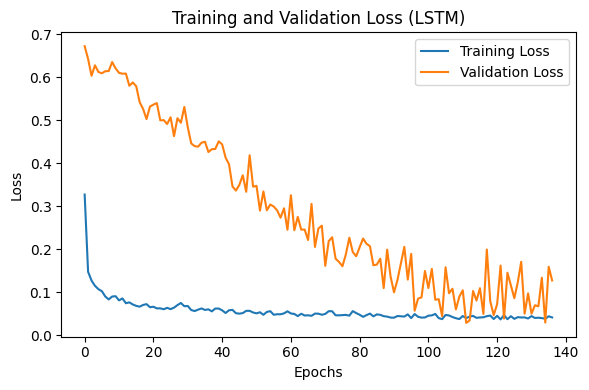

r2_train:   0.93719
r2_test:    0.77128
rmse_train: 6.2191
rmse_test:  4.2322


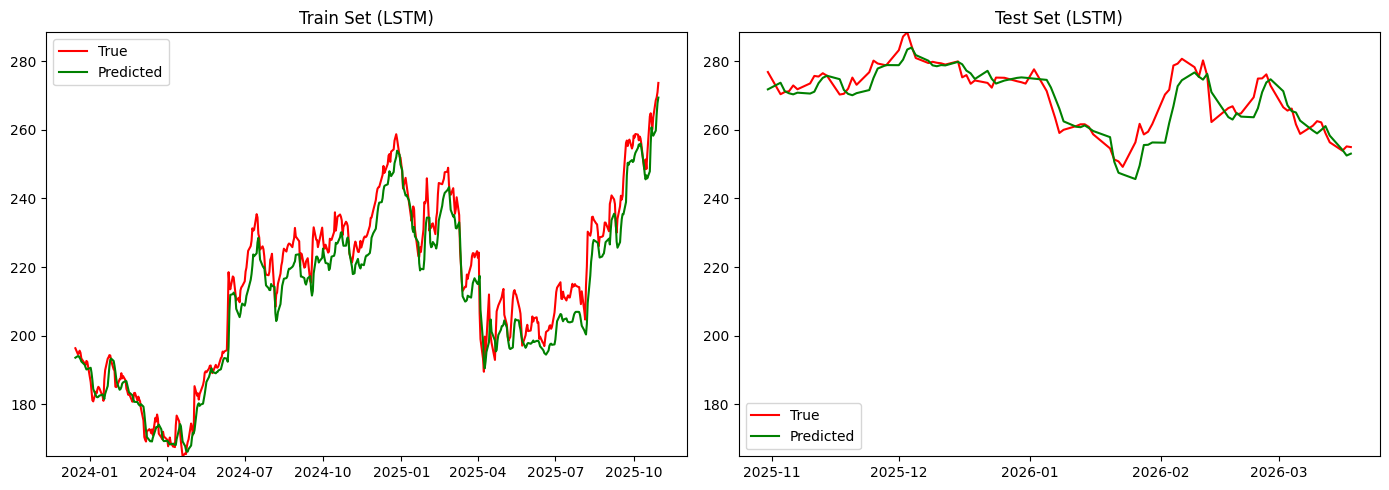

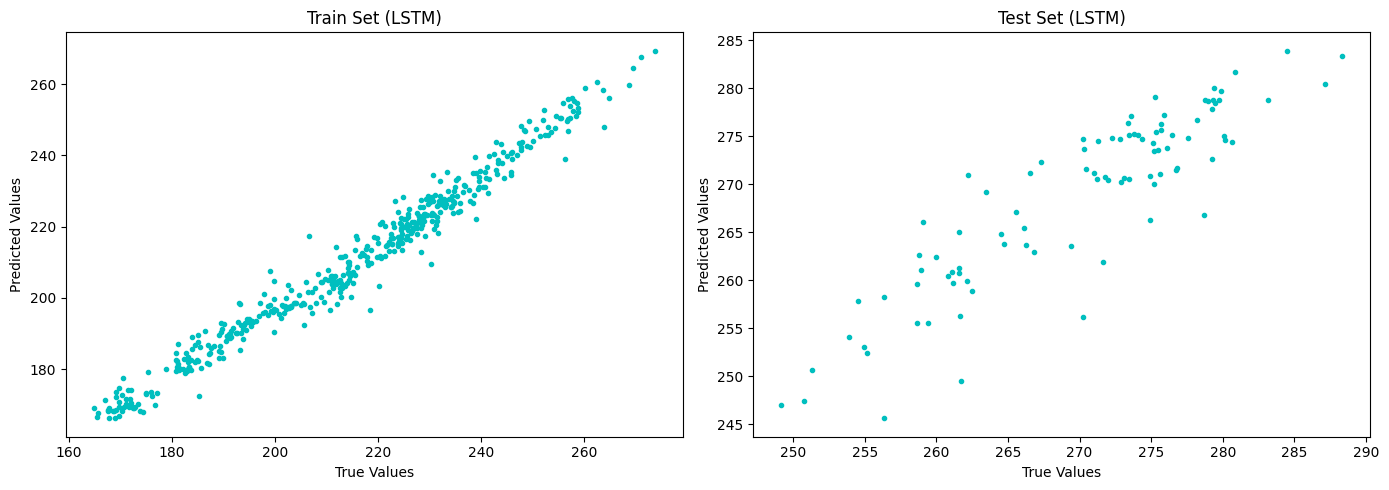

MAE:
  Train: 5.1836
  Test:  3.1011
R^2:
  Train: 0.9372
  Test:  0.7713


In [44]:
n_splits = 5 # Assuming n_splits is 5 as used in previous CV
kf_time_series_reget = TimeSeriesSplit(n_splits=n_splits)

last_train_index = None
last_test_index = None
last_y_train_fold = None
last_y_test_fold = None
last_scaler_y_cv = None

# Iterate through the splits to get the data and scaler for the last fold
# X_recent_2d is assumed to be available from prior cells.
for i, (tr_idx, ts_idx) in enumerate(kf_time_series_reget.split(X_recent_2d)):
    if i == n_splits - 1: # This is the last fold
        last_train_index = tr_idx
        last_test_index = ts_idx
        last_y_train_fold = y_recent[tr_idx]
        last_y_test_fold = y_recent[ts_idx]

        # Recreate scaler_y_cv for the last fold to ensure consistency
        temp_scaler_y_cv = MinMaxScaler(feature_range=(0,1))
        temp_scaler_y_cv.fit(last_y_train_fold.reshape(-1, 1))
        last_scaler_y_cv = temp_scaler_y_cv
        break


y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale using the correct scaler_y_cv
y_train_pred = last_scaler_y_cv.inverse_transform(y_train_pred_scaled)
y_test_pred  = last_scaler_y_cv.inverse_transform(y_test_pred_scaled)

# Now use the true values and dates from the last fold's split
y_train_true = last_y_train_fold.reshape(-1, 1)
y_test_true = last_y_test_fold.reshape(-1, 1)
dates_train_plot = dates_recent[last_train_index]
dates_test_plot = dates_recent[last_test_index]

# Create a figure with one subplot for loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot Training and Validation Loss
ax.plot(history_lstm_final.history['loss'], label='Training Loss')
ax.plot(history_lstm_final.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss (LSTM)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for LSTM model
r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

# Convert predictions to pandas Series with dates as index for plotting
y_train_pred_series = pd.Series(y_train_pred.flatten(), index=dates_train_plot)
y_test_pred_series  = pd.Series(y_test_pred.flatten(), index=dates_test_plot)

# Calculate global y-axis limits for consistent plotting
y_min = min(y_train_true.min(), y_train_pred_series.min(), y_test_true.min(), y_test_pred_series.min())
y_max = max(y_train_true.max(), y_train_pred_series.max(), y_test_true.max(), y_test_pred_series.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred_series, 'g', label='Predicted')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred_series, 'g', label='Predicted')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot scatter plots for train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred_series.values, 'c.')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred_series.values, 'c.')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

### Training `model_lstm_final` on a Specific Fold (e.g., Fold 4)

To demonstrate how to train and evaluate the `model_lstm_final` on a specific fold, we will perform the following steps for **Fold 4**:

1.  **Iterate through the `TimeSeriesSplit`** to get the `train_index` and `test_index` for Fold 4.
2.  **Extract the data** (`X_train_fold_4`, `y_train_fold_4`, `X_test_fold_4`, `y_test_fold_4`, `dates_train_fold_4`, `dates_test_fold_4`).
3.  **Scale the data** using new `MinMaxScaler` instances (`scaler_X_fold_4`, `scaler_y_fold_4`) to prevent data leakage from other folds.
4.  **Reshape the scaled X data** to the 3D format required by the LSTM model.
5.  **Build a fresh `model_lstm_final`** with its optimizer and compile it.
6.  **Train the model** using the specific fold's scaled data.
7.  **Evaluate and plot the results** for Fold 4.

Extracted indices for Fold 4
Data for Fold 4 prepared and scaled.

Training model for Fold 4...
Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.2025 - val_loss: 0.5060
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1397 - val_loss: 0.5138
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1205 - val_loss: 0.4921
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1110 - val_loss: 0.4633
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1078 - val_loss: 0.4677
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0937 - val_loss: 0.4630
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0883 - val_loss: 0.4419
Epoch 8/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0857 - val_loss: 0.4581
Epoch 9/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0866 - val_loss: 0.4370
Epoch 10/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0863 - val_loss: 0.4289
Epoch 11/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.08

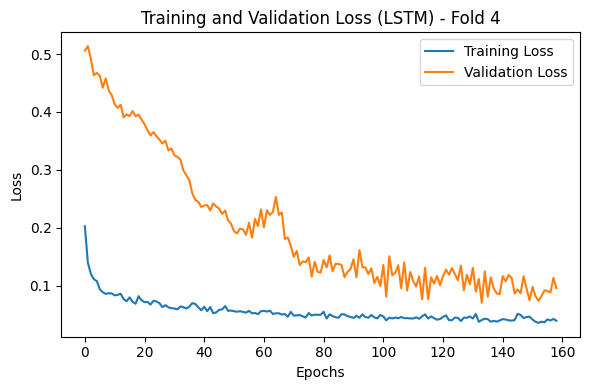

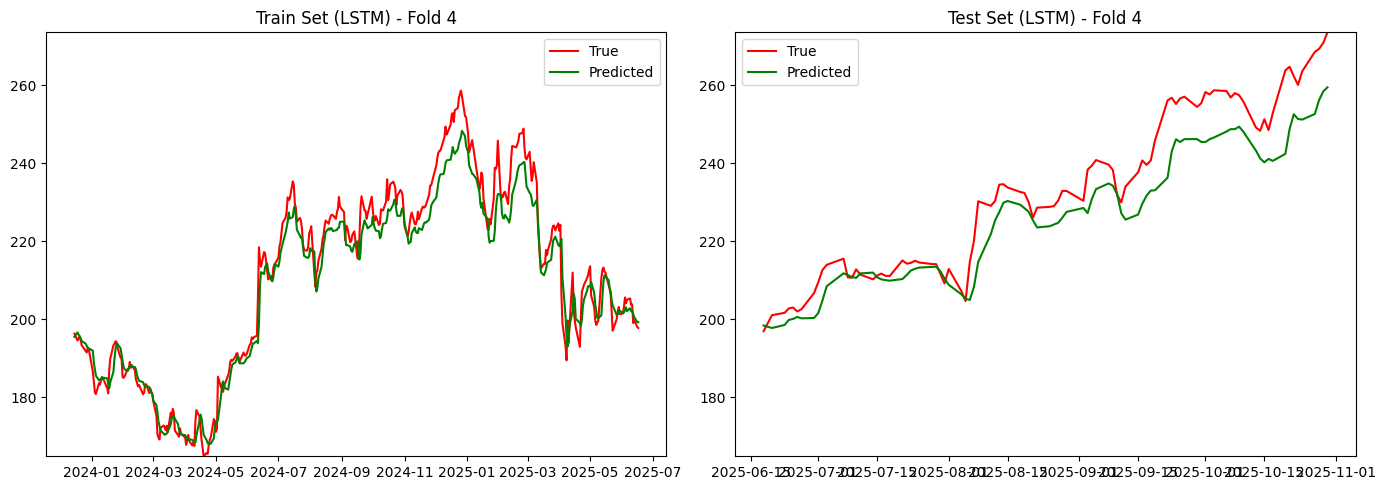

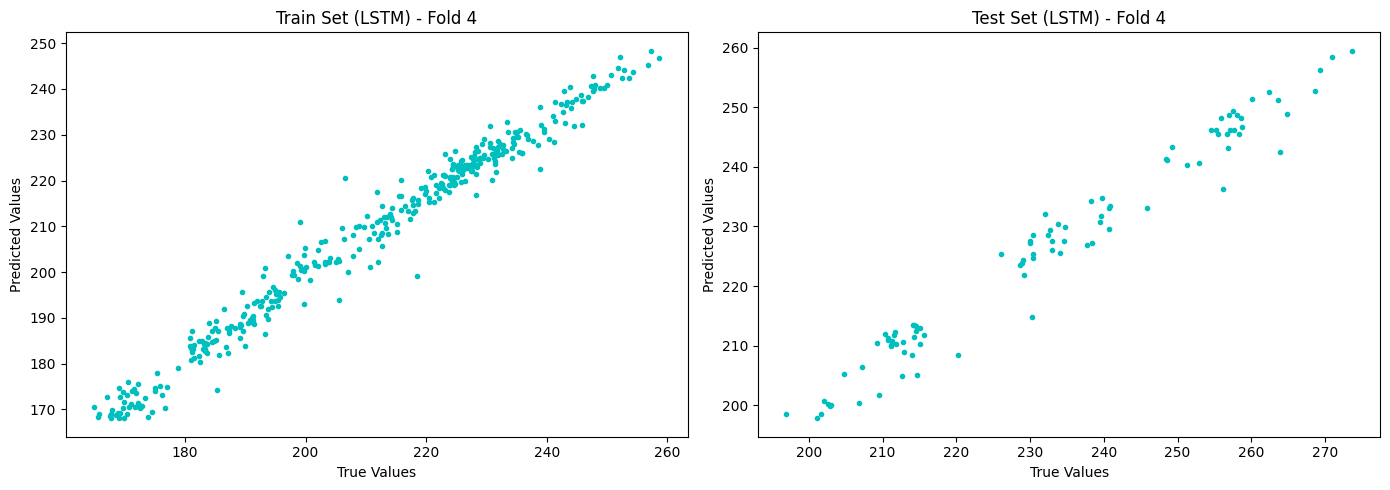

In [45]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Define the LSTM model building function
def build_lstm_model(window_size, num_features, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# Re-initialize TimeSeriesSplit
n_splits = 5
kf_time_series = TimeSeriesSplit(n_splits=n_splits)

# X_recent_2d was already created in cell 5fe8341e
# We will iterate to get the 4th fold's indices

selected_fold = 4
current_fold = 0

for train_index, test_index in kf_time_series.split(X_recent_2d):
    current_fold += 1
    if current_fold == selected_fold:
        # Store the indices for the selected fold
        train_index_4 = train_index
        test_index_4 = test_index
        break

print(f"Extracted indices for Fold {selected_fold}")

# Extract data for Fold 4
X_train_fold_4_2d = X_recent_2d[train_index_4]
X_test_fold_4_2d  = X_recent_2d[test_index_4]
y_train_fold_4    = y_recent[train_index_4]
y_test_fold_4     = y_recent[test_index_4]
dates_train_fold_4 = dates_recent[train_index_4]
dates_test_fold_4  = dates_recent[test_index_4]

# Scale data for Fold 4
scaler_X_fold_4 = MinMaxScaler(feature_range=(0, 1))
scaler_y_fold_4 = MinMaxScaler(feature_range=(0, 1))

X_train_scaled_fold_4_2d = scaler_X_fold_4.fit_transform(X_train_fold_4_2d)
X_test_scaled_fold_4_2d  = scaler_X_fold_4.transform(X_test_fold_4_2d)

y_train_scaled_fold_4 = scaler_y_fold_4.fit_transform(y_train_fold_4.reshape(-1, 1))
y_test_scaled_fold_4  = scaler_y_fold_4.transform(y_test_fold_4.reshape(-1, 1))

# Reshape scaled X data to 3D for LSTM input
current_window_size = X_recent.shape[1] # This should be 10
current_num_features = X_recent.shape[2] # This should be 5

X_train_scaled_3d_fold_4 = X_train_scaled_fold_4_2d.reshape((X_train_scaled_fold_4_2d.shape[0], current_window_size, current_num_features))
X_test_scaled_3d_fold_4  = X_test_scaled_fold_4_2d.reshape((X_test_scaled_fold_4_2d.shape[0], current_window_size, current_num_features))

print("Data for Fold 4 prepared and scaled.")

# Build a fresh model for Fold 4
model_lstm_fold_4 = build_lstm_model(
    current_window_size,
    current_num_features,
    dropout_rate=0.2,
    learning_rate=0.001 # Use the optimized learning rate
)

# Early stopping callback
early_stopping_fold_4 = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

print(f"\nTraining model for Fold {selected_fold}...")
history_lstm_fold_4 = model_lstm_fold_4.fit(
    X_train_scaled_3d_fold_4, y_train_scaled_fold_4,
    epochs=250,
    batch_size=64,
    validation_data=(X_test_scaled_3d_fold_4, y_test_scaled_fold_4),
    verbose=1,
    callbacks=[early_stopping_fold_4]
)

print(f"\nEvaluation for Fold {selected_fold}:")
# Get predictions
y_train_pred_scaled_fold_4 = model_lstm_fold_4.predict(X_train_scaled_3d_fold_4)
y_test_pred_scaled_fold_4  = model_lstm_fold_4.predict(X_test_scaled_3d_fold_4)

# Inverse transform predictions to original scale
y_train_pred_fold_4 = scaler_y_fold_4.inverse_transform(y_train_pred_scaled_fold_4)
y_test_pred_fold_4  = scaler_y_fold_4.inverse_transform(y_test_pred_scaled_fold_4)

# Calculate metrics
r2_train_fold_4 = r2_score(y_train_fold_4, y_train_pred_fold_4)
r2_test_fold_4  = r2_score(y_test_fold_4, y_test_pred_fold_4)

rmse_train_fold_4 = mean_squared_error(y_train_fold_4, y_train_pred_fold_4)**0.5
rmse_test_fold_4  = mean_squared_error(y_test_fold_4, y_test_pred_fold_4)**0.5

mae_train_fold_4 = mean_absolute_error(y_train_fold_4, y_train_pred_fold_4)
mae_test_fold_4  = mean_absolute_error(y_test_fold_4, y_test_pred_fold_4)

print("MAE:")
print(f"  Train: {mae_train_fold_4:.4f}")
print(f"  Test:  {mae_test_fold_4:.4f}")
print("R^2:")
print(f"  Train: {r2_train_fold_4:.4f}")
print(f"  Test:  {r2_test_fold_4:.4f}")

# Plotting for Fold 4
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(history_lstm_fold_4.history['loss'], label='Training Loss')
ax.plot(history_lstm_fold_4.history['val_loss'], label='Validation Loss')
ax.set_title(f'Training and Validation Loss (LSTM) - Fold {selected_fold}')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

y_train_pred_series_fold_4 = pd.Series(y_train_pred_fold_4.flatten(), index=dates_train_fold_4)
y_test_pred_series_fold_4  = pd.Series(y_test_pred_fold_4.flatten(), index=dates_test_fold_4)

y_min_fold_4 = min(y_train_fold_4.min(), y_train_pred_series_fold_4.min(), y_test_fold_4.min(), y_test_pred_series_fold_4.min())
y_max_fold_4 = max(y_train_fold_4.max(), y_train_pred_series_fold_4.max(), y_test_fold_4.max(), y_test_pred_series_fold_4.max())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_fold_4, y_train_fold_4, 'r', label='True')
axs[0].plot(y_train_pred_series_fold_4, 'g', label='Predicted')
axs[0].set_title(f'Train Set (LSTM) - Fold {selected_fold}')
axs[0].set_ylim(y_min_fold_4, y_max_fold_4)
axs[0].legend()

axs[1].plot(dates_test_fold_4, y_test_fold_4, 'r', label='True')
axs[1].plot(y_test_pred_series_fold_4, 'g', label='Predicted')
axs[1].set_title(f'Test Set (LSTM) - Fold {selected_fold}')
axs[1].set_ylim(y_min_fold_4, y_max_fold_4)
axs[1].legend()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_fold_4, y_train_pred_series_fold_4.values, 'c.')
axs[0].set_title(f'Train Set (LSTM) - Fold {selected_fold}')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')

axs[1].plot(y_test_fold_4, y_test_pred_series_fold_4.values, 'c.')
axs[1].set_title(f'Test Set (LSTM) - Fold {selected_fold}')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')

plt.tight_layout()
plt.show()

### Saving the Trained Model for Specific Fold (e.g., Fold 4)

Now, we will save the `model_lstm_fold_4` which was specifically trained and evaluated on **Fold 4**. This allows you to retain the model's weights and configuration from this particular cross-validation split.

In [46]:
import joblib
model_lstm_fold_4.save('lstm_model_fold_4.keras')
print("LSTM model for Fold 4 saved as 'lstm_model_fold_4.keras'")

# Save the X scaler specific to Fold 4
joblib.dump(scaler_X_fold_4, 'scaler_X_fold_4.pkl')
print("X scaler for Fold 4 saved as 'scaler_X_fold_4.pkl'")

# Save the y scaler specific to Fold 4
joblib.dump(scaler_y_fold_4, 'scaler_y_fold_4.pkl')
print("Y scaler for Fold 4 saved as 'scaler_y_fold_4.pkl'")

LSTM model for Fold 4 saved as 'lstm_model_fold_4.keras'
X scaler for Fold 4 saved as 'scaler_X_fold_4.pkl'
Y scaler for Fold 4 saved as 'scaler_y_fold_4.pkl'


### Saving the Trained Model and Scalers

Now, we will save the retrained LSTM model (`lstm_model.keras`), the fitted X-scaler (`scaler_X.pkl`), and the fitted y-scaler (`scaler_y.pkl`) to your project directory. These files can be loaded later to make new predictions without retraining or re-fitting the scalers.

In [47]:
# Save the LSTM model
model_lstm_final.save('lstm_model.keras')
print("LSTM model saved as 'lstm_model.keras'")

# Save the X scaler
joblib.dump(scaler_X_final, 'scaler_X.pkl')
print("X scaler saved as 'scaler_X.pkl'")

# Save the y scaler
joblib.dump(scaler_y_final, 'scaler_y.pkl')
print("Y scaler saved as 'scaler_y.pkl'")

LSTM model saved as 'lstm_model.keras'
X scaler saved as 'scaler_X.pkl'
Y scaler saved as 'scaler_y.pkl'


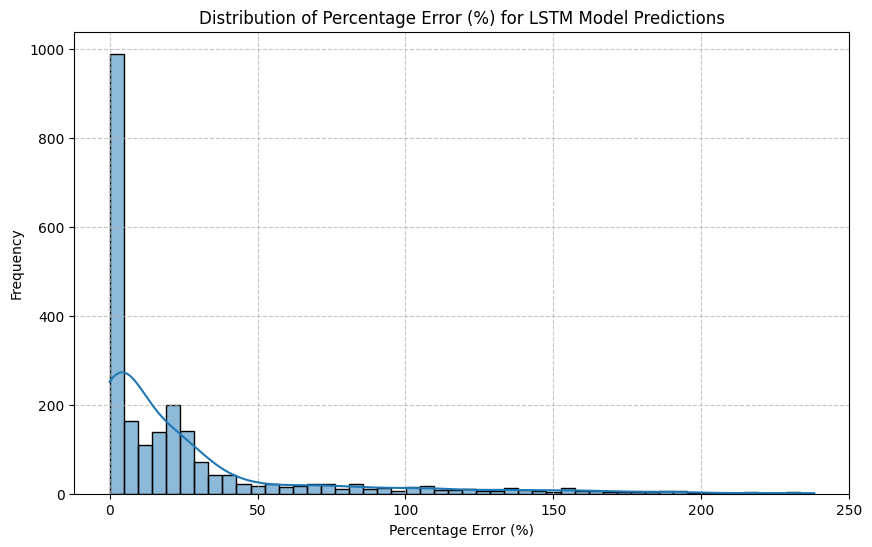

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(predicted_results_df_corrected['Percentage Error (%)'], bins=50, kde=True)
plt.title('Distribution of Percentage Error (%) for LSTM Model Predictions')
plt.xlabel('Percentage Error (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()